In [104]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout
from statsmodels.sandbox.distributions.genpareto import meanexcess

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)
df = df[df['RMSE_MAX'] < 1.2]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = (dv - dv.mean()) / dv.std()
df_norm['sid'] = df['sid']
df_norm['RMSE_MAX'] = df['RMSE_MAX']
df_norm.shape

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_2674/2273053767.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


(4928, 20)

In [103]:
df_grp

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark,RMSE_MAX
id,,,,,,,,,,,,,,,,,,,
0,-2.045318,3.186594,4843.351673,27.074129,0.000557,1.177955,-3.806249,-4.988886,0.001462,1.066887,4.107362e-07,-2.969391,0.933285,0.264638,0.555558,8.672069,-0.383111,0.004759,0.993863
1,-2.044543,3.826825,5278.675971,11.367265,0.000457,0.505938,-3.857689,-5.043308,0.001162,0.949152,4.578512e-07,-2.812980,0.915338,0.262268,0.503314,10.557331,-0.526195,0.004152,0.995816
2,-2.079532,3.803444,5004.046126,82.889510,0.000875,0.360265,-3.799023,-4.936568,0.003411,1.084427,5.697314e-07,-2.946235,0.922306,0.271992,0.718453,8.449119,-0.319276,0.010476,1.192405
4,-2.068768,3.269017,4852.615434,59.673924,0.000522,0.248967,-3.637790,-4.849668,0.001228,1.072116,3.198393e-07,-3.327106,0.920417,0.253098,0.653997,8.976881,-0.334696,0.003897,1.066682
9,-2.011352,2.958320,5155.036509,78.453951,0.000546,0.070255,-3.980779,-5.280733,0.001719,1.175260,2.794679e-07,-3.454413,0.911273,0.259468,0.950919,11.036705,-0.165050,0.006310,1.195313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2450,-2.048776,3.519388,5438.906849,83.921414,0.000752,0.232061,-3.952032,-5.234489,0.002902,1.069166,2.517647e-07,-2.763745,0.930892,0.258684,0.681867,5.252275,0.002019,0.009439,1.170761
2452,-2.037950,3.030611,5647.930456,92.467725,0.000789,0.068213,-3.798388,-4.958785,0.002546,1.086441,3.692673e-07,-3.077138,0.915896,0.262745,1.001482,8.382914,-0.265331,0.008070,1.043383
2454,-2.040558,3.549103,5564.337549,73.319045,0.000338,0.092714,-4.004009,-5.181698,0.000971,1.005880,4.476175e-07,-2.948228,0.936452,0.278637,0.547525,10.996352,-0.584661,0.004187,1.161413


In [2]:

vars_all

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'g1',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'anet_max',
 'root_area_index',
 'wcont_sigma_deviation',
 'g_bark']

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

In [13]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

RandomForestClassifier(class_weight='balanced', max_depth=2, random_state=2909)

In [62]:
imps = []

for i in range(0, 2):
    
    if i == 0:
        svars = vars_all
    else:
        svars = vars_plant
    X_train, X_test, y_train, y_test = train_test_split(df_norm[svars], df_norm['alive'], test_size=0.3, random_state=42)
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10, 
        random_state=2909, class_weight='balanced')
    rf.fit(X_train, y_train)
    print(rf.score(X_train, y_train))
    print(rf.score(X_test, y_test))

    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="accuracy",  # we can use any metric
        n_repeats=200,
        random_state=42,
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps.append(importance)


1.0
1.0
0.9080893012467381
0.786342123056119


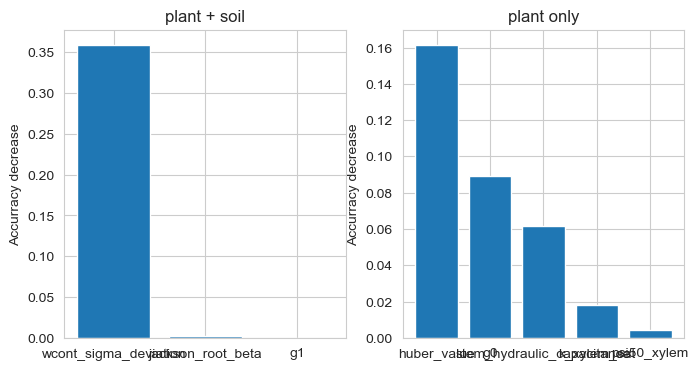

In [75]:
var_labs_size = [3,5]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 4))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])
    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
plt.show()

In [152]:
imps_regress[0]

,importance_mean,importance_std
stem_hydraulic_capacitance,0.320611,0.033348
k_xylem_sat,0.273321,0.036033
g0,0.264040,0.038260
huber_value,0.129888,0.016300
g_bark,0.090004,0.014899
leaf_hydraulic_capacitance,0.031063,0.007333
wcont_sigma_deviation,0.005555,0.003875
d_50_close,0.005445,0.005646
anet_max,0.003743,0.003594
psi50_xylem,0.003297,0.001912


In [89]:
labs_all =[r"$\sigma_\mathrm{wcont}$", r"Root $\beta$",r"$g_1$"]

labs_plant =[ r"Huber", r"$g_0$",r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl}$", r"$\psi_{50}$",r"$\Gamma_\mathrm{Leaf}$"]

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_2674/3682130178.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_all)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_2674/3682130178.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_plant)


ValueError: num must be an integer with 1 <= num <= 2, not 3

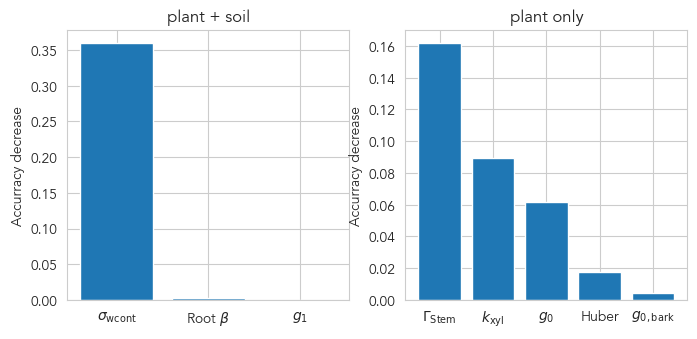

In [174]:
plt.rcParams["font.family"] = "Avenir"
var_labs_size = [3,5]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 3.5))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])
    if i == 0:
        ax.set_xticklabels(labs_all)
    else:
        ax.set_xticklabels(labs_plant)
    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F2_RF_classifier.png"), bbox_inches='tight', dpi=300)
plt.show()


In [168]:
imps_regress = []
from sklearn import metrics

for i in range(0, 2):
    if i == 0:
        dfs_norm = df_norm[df_norm['sid'] == 0]
    else:
        dfs_norm = df_norm[df_norm['sid'] > 0]
        
    X_train, X_test, y_train, y_test = train_test_split(dfs_norm[vars_all], dfs_norm['RMSE_MAX'], test_size=0.3, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20, 
        random_state=2909)
    
    rf.fit(X_train, y_train)
    
    print(rf.score(X_train, y_train))
    
    print('Root Mean Squared Error (RMSE) train:', metrics.root_mean_squared_error(y_train, rf.predict(X_train)))
    print('Root Mean Squared Error (RMSE) test:', metrics.root_mean_squared_error(y_test, rf.predict(X_test)))
    


    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="neg_root_mean_squared_error",  # we can use any metric
        n_repeats=200,
        random_state=42,
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps_regress.append(importance)

0.9342429443457382
Root Mean Squared Error (RMSE) train: 0.019389197450979546
Root Mean Squared Error (RMSE) test: 0.05032694426417371
0.9469696277314535
Root Mean Squared Error (RMSE) train: 0.016979584834409166
Root Mean Squared Error (RMSE) test: 0.04763972311663021


In [170]:
imps_regress[1]

,importance_mean,importance_std
k_xylem_sat,0.022709,0.000950
wcont_sigma_deviation,0.009275,0.000748
stem_hydraulic_capacitance,0.007829,0.000493
psi88_xylem,0.005314,0.000507
pore_0,0.004478,0.000587
g0,0.003466,0.000303
huber_value,0.001805,0.000225
g_bark,0.001692,0.000148
leaf_hydraulic_capacitance,0.001625,0.000277
psi_leaf_50_close,0.001109,0.000268


/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_2674/3355812035.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_alive)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_2674/3355812035.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_dead)


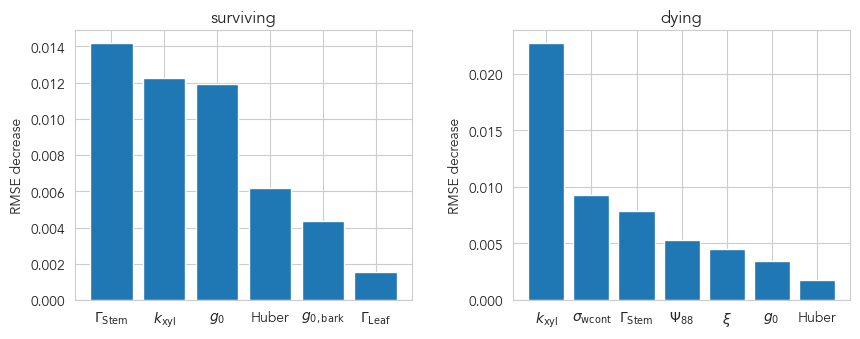

In [173]:
var_labs_size = [6, 7]
labs_alive =[  r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl}$", r"$g_0$",r"Huber", r"$g_\mathrm{0,bark}$",r"$\Gamma_\mathrm{Leaf}$"]
labs_dead =[  r"$k_\mathrm{xyl}$",r"$\sigma_\mathrm{wcont}$",r"$\Gamma_\mathrm{Stem}$", r"$\Psi_{88}$", r"$\xi$",r"$g_0$",r"Huber"]
title_labs  = ["surviving", "dying"]
fig = plt.figure(figsize=(10, 3.5))
for i in range(0, 2):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps_regress[i][0:var_labs_size[i]].index,imps_regress[i][0:var_labs_size[i]]['importance_mean'])
    if i == 0:
        ax.set_xticklabels(labs_alive)
    else:
        ax.set_xticklabels(labs_dead)
    ax.set_title(title_labs[i])
    ax.set_ylabel("RMSE decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F3_RF_regressor.png"), bbox_inches='tight', dpi=300)
plt.show()

In [122]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark,sid,RMSE_MAX
9694,0.863460,-0.815831,-0.230385,-1.536295,0.650222,0.031730,-1.700508,-0.826496,-0.786026,-0.504079,-0.446972,-1.363500,-1.069955,-1.531748,-0.691446,-1.103399,-0.811093,0.092082,4,0.856748
9693,0.435564,0.054784,0.964615,-1.645642,1.232742,-0.227608,0.771542,1.292998,-0.160360,-0.692526,1.968417,-0.206942,-0.945712,-1.295545,-0.995928,-1.080906,-0.950198,0.182189,3,0.856748
9690,0.971092,-0.245220,0.586887,-1.572429,0.961512,-0.217059,-0.310023,-0.815212,-0.268877,0.525090,0.990119,-1.190320,2.170258,0.831799,-0.478827,-1.018228,1.804192,-0.075589,0,0.856748
9691,0.472228,0.118481,-0.233392,-1.568801,1.609507,-0.224049,-0.047777,-0.919153,-0.561240,-0.951281,1.671560,1.116446,0.527867,-0.257586,-1.254879,-1.001008,-1.133769,0.077028,1,0.856748
3021,0.902103,1.100641,0.150678,-1.003528,0.788703,-0.819653,-1.082580,-0.807262,-0.750143,-1.215712,2.043297,0.847526,-0.053452,-0.923068,-0.404184,-1.831885,-0.617057,-0.088492,1,0.877322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8975,0.598934,-0.294760,-2.217293,-0.600966,0.725864,-1.405769,0.288381,-0.439409,0.584725,1.374583,0.410668,-1.645094,2.049457,2.037013,1.462008,-0.306289,1.324590,1.466256,0,1.199474
8676,-0.699165,-1.897043,1.185923,1.397876,0.144543,-1.323605,0.227819,0.740979,1.565313,-1.220493,-1.188553,1.329560,-1.078439,-0.805513,0.366685,-0.172004,0.937008,1.743710,1,1.199957
8675,-0.083124,-0.489227,0.477045,1.423216,-0.960961,-1.604985,-0.284073,-0.808148,2.453786,1.352323,0.380259,-1.133202,2.038952,1.985048,1.697159,0.495987,1.224144,0.881468,0,1.199957
8678,0.950461,-1.254002,0.842273,1.464758,0.255703,-1.375374,0.747798,-0.321762,2.465962,0.593364,-1.110569,0.869747,-0.946074,-1.524985,0.265227,0.648485,0.862172,0.857830,3,1.199957


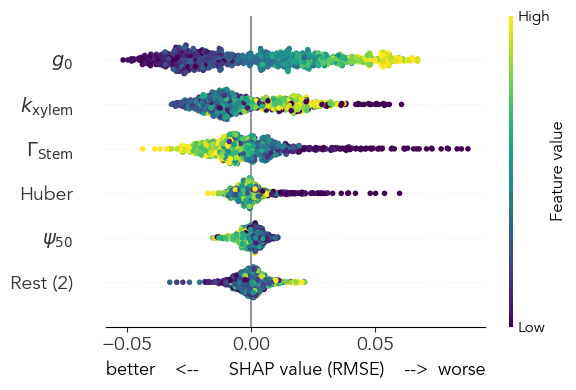

In [194]:
labs = list(reversed([r"$g_{0}$", r"$k_\mathrm{xylem}$", r"$\Gamma_\mathrm{Stem}$", r"Huber"
                     , r"$\psi_{50}$", "Rest (2)"]))
shap.plots.beeswarm(shap_values[:,:], color="viridis", max_display=6, show = False, plot_size=[6,4])
ax = plt.gca()
ax.set_xlabel("better    <--      SHAP value (RMSE)    -->  worse")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Figure_2_shap_values_plant_RMSE.png'), dpi=300)
plt.show()

In [183]:

labs = list(reversed([r"$\psi_{50}$", r"$\Gamma_\mathrm{Stem}$", r"Huber", r"Root $\beta$",
                      r"$k_\mathrm{xylem}$", r"$g_0$", r"$\Gamma_\mathrm{Leaf}$"]))
# print(labs)
import matplotlib as mpl

plt.rcParams["font.family"] = "Avenir"
shap.plots.beeswarm(shap_values[:, :, 1], color="viridis", max_display=7, show=False)
ax = plt.gca()
ax.set_xlabel("more dead    <--      SHAP value (alive)     -->   more alive")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Figure_2_shap_values_plant_RMSE.png'), dpi=300)
plt.show()

IndexError: too many indices for array